# <center>**IROS**<center>

**Libraries**

In [1]:
import numpy as np
import mbloodmoon as bm
from iros_wrappers import perform_iros, compare_w_catalog
from iros_wrappers import gen_log, computes_params
from iros_wrappers import save_iros_output, load_iros_output
from iros_wrappers import save_iros_data, load_iros_data
from iros_wrappers import save_pickle, load_pickle

ModuleNotFoundError: No module named 'iros_wrappers'

- Let's set up IROS

In [2]:
root_path = "/mnt/d/PhD_AASS/Coding/Images_fits/"
mask_file = root_path + "wfm_mask.fits"
simul_data = root_path + "iros_simulation_GC_LMC/20241011_galctr_rxte_sax_2-30keV_1ks_2cams_sources_cxb/"

cam_a = "cam1a"
cam_b = "cam1b"
dataset = "reconstructed"

filepaths = bm.simulation_files(simul_data)
wfm = bm.codedmask(mask_file, upscale_x=5, upscale_y=1)
sdlA = bm.simulation(filepaths[cam_a][dataset])
sdlB = bm.simulation(filepaths[cam_b][dataset])

max_iterations = 25
snr_threshold = 5

n_test = 0

- If IROS has been ran earlier and a FITS has been saved, this file will be loaded. If not, IROS will be launched.

In [ ]:
iros_output_name = root_path + f"iros_output{n_test}.fits"

try:
    iros_output = load_iros_output(iros_output_name)
except FileNotFoundError:
    iros_output, residuals = perform_iros(
        wfm=wfm,
        sdlA=sdlA,
        sdlB=sdlB,
        cameras=(cam_a, cam_b),
        max_iterations=max_iterations,
        snr_threshold=snr_threshold,
    )

    save_iros_output(iros_output, mask_file, iros_output_name)

# Loading data...
# Loading completed!


In [4]:
iros_output

{'cam1a': {'shiftx': array([ 4.39241036e+01,  1.35523470e+01, -2.81355985e+01,  5.36045374e+01,
          2.98728113e+01, -6.46000000e+01,  8.44090305e+00,  4.19000238e+01,
         -6.24793145e+00, -1.34670554e+02,  4.29968241e+01, -4.17595197e+01,
         -5.63700687e+01,  1.74994035e+02, -5.63999856e+01, -1.75081011e+01,
         -9.86081496e+01,  1.37603183e+02, -2.78127621e+01, -1.63021423e-01,
         -2.05250002e+02, -2.03513167e+02, -1.67664250e+02, -1.66402909e+02,
         -1.30300000e+02], dtype='>f8'),
  'shifty': array([  78.37877528,  -12.38659266,   29.15177642,  -26.77957834,
          -13.16681316,   39.00123457,   -1.94002471,  -24.54695805,
          -28.89931966,   82.32886906,   12.31392703,   36.15653489,
            6.4244692 , -106.54616734,   25.23177203,   10.5135971 ,
           35.59862469,  -59.16595899,   26.40004783,    1.09704373,
          171.6136466 ,  191.20000811,  178.01207831,  188.32923957,
          181.50574209], dtype='>f8'),
  'fluence': ar

- Let's take the output from the IROS loop and compute the useful parameters

In [4]:
iros_data_name = root_path + f"iros_data{n_test}.fits"

try:
    iros_data = load_iros_data(iros_data_name)

except FileNotFoundError:
    log = gen_log((cam_a, cam_b))

    iros_data = computes_params(
        iros_output=iros_output,
        wfm=wfm,
        sdlA=sdlA,
        sdlB=sdlB,
        log=log,
    )

    save_iros_data(
        data=iros_data,
        mask_file=mask_file,
        sdls=(sdlA, sdlB),
        save_to=iros_data_name,
    )

# Loading data...
# Loading completed!


In [5]:
iros_data

{'cam1a': {'y': {'data': array([711, 485, 588, 449, 483, 613, 511, 454, 443, 721, 546, 606, 532,
          249, 579, 542, 604, 368, 582, 518, 945, 994, 961, 986, 969],
         dtype='>i4'),
   'format': 'J',
   'unit': 'px'},
  'x': {'data': array([5057, 4450, 3616, 5251, 4776, 2887, 4347, 5017, 4054, 1485, 5038,
          3343, 3051, 7678, 3051, 3828, 2206, 6931, 3622, 4175,   73,  108,
           825,  850, 1573], dtype='>i4'),
   'format': 'J',
   'unit': 'px'},
  'shift_x': {'data': array([ 4.39241036e+01,  1.35523470e+01, -2.81355985e+01,  5.36045374e+01,
           2.98728113e+01, -6.46000000e+01,  8.44090305e+00,  4.19000238e+01,
          -6.24793145e+00, -1.34670554e+02,  4.29968241e+01, -4.17595197e+01,
          -5.63700687e+01,  1.74994035e+02, -5.63999856e+01, -1.75081011e+01,
          -9.86081496e+01,  1.37603183e+02, -2.78127621e+01, -1.63021423e-01,
          -2.05250002e+02, -2.03513167e+02, -1.67664250e+02, -1.66402909e+02,
          -1.30300000e+02], dtype='>f8'),


In [4]:
dataset_name = root_path + f"database{n_test}.fits"

try:
    dataset = load_iros_data(dataset_name)

except FileNotFoundError:
    catalogA = filepaths[cam_a]["sources"]
    catalogB = filepaths[cam_b]["sources"]

    dataset = compare_w_catalog(
        data=iros_data,
        catalogA=catalogA,
        catalogB=catalogB,
        cameras=(cam_a, cam_b),
        min_flux=0.1,
    )

    save_iros_data(
        data=dataset,
        mask_file=mask_file,
        sdls=(sdlA, sdlB),
        save_to=dataset_name,
    )


# Loading data...
# Loading completed!


In [5]:
dataset

{'cam1a': {'y': {'data': array([711, 485, 588, 449, 483, 613, 511, 454, 443, 721, 546, 606, 532,
          249, 579, 542, 604, 368, 582], dtype='>i4'),
   'format': 'J',
   'unit': 'px'},
  'x': {'data': array([5057, 4450, 3616, 5251, 4776, 2887, 4347, 5017, 4054, 1485, 5038,
          3343, 3051, 7678, 3051, 3828, 2206, 6931, 3622], dtype='>i4'),
   'format': 'J',
   'unit': 'px'},
  'shift_x': {'data': array([  43.9241036 ,   13.55234697,  -28.13559855,   53.60453744,
            29.87281134,  -64.6       ,    8.44090305,   41.90002383,
            -6.24793145, -134.67055429,   42.9968241 ,  -41.75951971,
           -56.37006871,  174.9940355 ,  -56.39998558,  -17.50810109,
           -98.6081496 ,  137.60318316,  -27.81276214], dtype='>f8'),
   'format': 'D',
   'unit': 'mm'},
  'dshift_x': {'data': array([0.025, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025,
          0.025, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025, 0.025,
          0.025], dtype='>f8'),
   'format'

In [6]:
catalogA = bm.simulation(filepaths[cam_a]["sources"])
catalogB = bm.simulation(filepaths[cam_b]["sources"])

In [7]:
def check_pos(
    iros_data: dict,
    catalogs: tuple,
    sigma: int | float = 5,
) -> None:

    source_in_errbox_camA = []
    source_in_errbox_camB = []
    errboxes = (source_in_errbox_camA, source_in_errbox_camB)

    for cat, camera, errbox in zip(
        catalogs,
        iros_data.keys(),
        errboxes,
    ):
        print(f"# CAMERA {camera.upper()}, {sigma} SIGMA ERRBOX")
        for name, ra, dec, dra, ddec in zip(
            iros_data[camera]["catalog_name"]["data"],
            iros_data[camera]["ra"]["data"],
            iros_data[camera]["dec"]["data"],
            iros_data[camera]["dra"]["data"],
            iros_data[camera]["ddec"]["data"],
        ):
            cat_source_ra = cat.data[cat.data["NAME"] == name]["RA"][0]
            cat_source_dec = cat.data[cat.data["NAME"] == name]["DEC"][0]
            errbox.append(
                int((np.abs(cat_source_ra - ra) < sigma*dra) & (np.abs(cat_source_dec - dec) < sigma*ddec)),
            )
                
            print(
                f"  - {name.upper()} inside error box: {bool(errbox[-1])}"
            )
    
        print(
            f"# IROS accuracy {camera.upper()}: {np.array(errbox).sum()*100/len(iros_data[camera]["catalog_name"]["data"]):0.2f}%\n"
        )
        

check_pos(
    iros_data=dataset,
    catalogs=(catalogA, catalogB),
    sigma=5,
)

# CAMERA CAM1A, 5 SIGMA ERRBOX
  - SCOX1 inside error box: True
  - GX5-1 inside error box: True
  - GX349+2 inside error box: True
  - GX17+2 inside error box: True
  - GX9+1 inside error box: True
  - GX340+0 inside error box: True
  - GX3+1 inside error box: True
  - GX13+1 inside error box: True
  - X1820-303 inside error box: True
  - CIRX1 inside error box: True
  - GX9+9 inside error box: True
  - GROJ1655-40 inside error box: True
  - X1735-444 inside error box: False
  - GRS1915+105 inside error box: False
  - X1705-440 inside error box: True
  - GX354-0 inside error box: True
  - X1636-536 inside error box: False
  - SERX1 inside error box: True
  - IGRJ17091-3624 inside error box: True
# IROS accuracy CAM1A: 84.21%

# CAMERA CAM1B, 5 SIGMA ERRBOX
  - SCOX1 inside error box: True
  - GX5-1 inside error box: True
  - GX349+2 inside error box: True
  - GX17+2 inside error box: True
  - GX9+1 inside error box: True
  - GX340+0 inside error box: True
  - GX3+1 inside error box: T

In [8]:
def check_counts(
    iros_data: dict,
    sdls: tuple,
    catalogs: tuple,
) -> None:

    for sdl, cat, camera in zip(
        sdls, catalogs, iros_data.keys(),
    ):
        print(f"# CAMERA {camera.upper()}\n")
        for name, f, of, sf, sp in zip(
            iros_data[camera]["catalog_name"]["data"],
            iros_data[camera]["fluence"]["data"],
            iros_data[camera]["obs_fluence"]["data"],
            iros_data[camera]["sub_fluence"]["data"],
            iros_data[camera]["simulphotons"]["data"],
        ):
            cat_source_ra = cat.data[cat.data["NAME"] == name]["RA"][0]
            cat_source_dec = cat.data[cat.data["NAME"] == name]["DEC"][0]
            # conv float64 to float32
            total_phs_simulated = len(
                sdl.data[(np.abs(sdl.data["RA"] - cat_source_ra) < 1e-7) & (np.abs(sdl.data["DEC"] - cat_source_dec) < 1e-7)]
            )
            print(
                f"  Counts stats for {name.upper()}:\n"
                f"    - Optimized wrt FITS: {f * 100 / total_phs_simulated:0.2f}%\n"
                f"    - Obs at peak wrt FITS: {of * 100 / total_phs_simulated:0.2f}%\n"
                f"    - Sub from sky wrt FITS: {sf * 100 / total_phs_simulated:0.2f}%\n"
                f"    - Retrieved wrt FITS: {sp * 100 / total_phs_simulated:0.2f}%\n"      # 5 sigma box around optim rec pos
            )


check_counts(
    iros_data=dataset,
    sdls=(sdlA, sdlB),
    catalogs=(catalogA, catalogB),
)

# CAMERA CAM1A

  Counts stats for SCOX1:
    - Optimized wrt FITS: 98.96%
    - Obs at peak wrt FITS: 92.97%
    - Sub from sky wrt FITS: 94.21%
    - Retrieved wrt FITS: 100.00%

  Counts stats for GX5-1:
    - Optimized wrt FITS: 102.64%
    - Obs at peak wrt FITS: 88.74%
    - Sub from sky wrt FITS: 88.82%
    - Retrieved wrt FITS: 100.00%

  Counts stats for GX349+2:
    - Optimized wrt FITS: 109.00%
    - Obs at peak wrt FITS: 94.67%
    - Sub from sky wrt FITS: 98.61%
    - Retrieved wrt FITS: 100.01%

  Counts stats for GX17+2:
    - Optimized wrt FITS: 107.43%
    - Obs at peak wrt FITS: 93.26%
    - Sub from sky wrt FITS: 93.85%
    - Retrieved wrt FITS: 100.00%

  Counts stats for GX9+1:
    - Optimized wrt FITS: 93.72%
    - Obs at peak wrt FITS: 91.04%
    - Sub from sky wrt FITS: 88.35%
    - Retrieved wrt FITS: 100.01%

  Counts stats for GX340+0:
    - Optimized wrt FITS: 102.05%
    - Obs at peak wrt FITS: 92.90%
    - Sub from sky wrt FITS: 89.22%
    - Retrieved wrt 

# CAMERA CAM1A
  - SCOX1 MSE: 0.005007
    SCOX1 MAE: 0.069315
  - GX5-1 MSE: 0.000721
    GX5-1 MAE: 0.026412
  - GX349+2 MSE: 0.007086
    GX349+2 MAE: 0.072265
  - GX17+2 MSE: 0.006226
    GX17+2 MAE: 0.067090
  - GX9+1 MSE: 0.001861
    GX9+1 MAE: 0.040172
  - GX340+0 MSE: 0.000363
    GX340+0 MAE: 0.019119
  - GX3+1 MSE: 0.000435
    GX3+1 MAE: 0.021260
  - GX13+1 MSE: 0.012701
    GX13+1 MAE: 0.087007
  - X1820-303 MSE: 0.006802
    X1820-303 MAE: 0.062256
  - CIRX1 MSE: 0.000245
    CIRX1 MAE: 0.018571
  - GX9+9 MSE: 0.003955
    GX9+9 MAE: 0.059629
  - GROJ1655-40 MSE: 0.000828
    GROJ1655-40 MAE: 0.022882
  - X1735-444 MSE: 0.312475
    X1735-444 MAE: 0.404898
  - GRS1915+105 MSE: 0.042906
    GRS1915+105 MAE: 0.185645
  - X1705-440 MSE: 0.064921
    X1705-440 MAE: 0.205057
  - GX354-0 MSE: 0.011236
    GX354-0 MAE: 0.086688
  - X1636-536 MSE: 0.365986
    X1636-536 MAE: 0.543677
  - SERX1 MSE: 0.001057
    SERX1 MAE: 0.039306
  - IGRJ17091-3624 MSE: 0.000362
    IGRJ17091-36

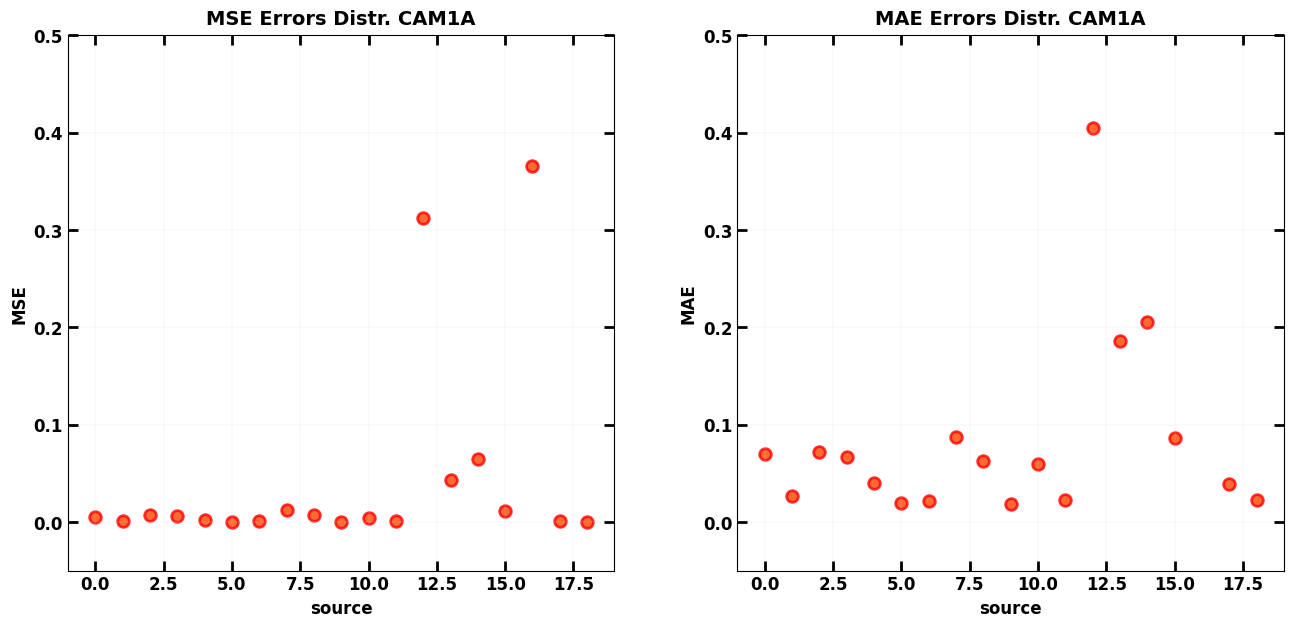



# CAMERA CAM1B
  - SCOX1 MSE: 0.011173
    SCOX1 MAE: 0.120566
  - GX5-1 MSE: 0.031481
    GX5-1 MAE: 0.177988
  - GX349+2 MSE: 0.008783
    GX349+2 MAE: 0.103140
  - GX17+2 MSE: 0.007180
    GX17+2 MAE: 0.087001
  - GX9+1 MSE: 0.002783
    GX9+1 MAE: 0.054880
  - GX340+0 MSE: 0.023565
    GX340+0 MAE: 0.173159
  - GX3+1 MSE: 0.009442
    GX3+1 MAE: 0.101101
  - GX13+1 MSE: 0.038122
    GX13+1 MAE: 0.199642
  - X1820-303 MSE: 0.042899
    X1820-303 MAE: 0.213184
  - CIRX1 MSE: 0.013920
    CIRX1 MAE: 0.144497
  - GX9+9 MSE: 0.007279
    GX9+9 MAE: 0.090288
  - GROJ1655-40 MSE: 0.002531
    GROJ1655-40 MAE: 0.059557
  - X1735-444 MSE: 0.153025
    X1735-444 MAE: 0.399695
  - GRS1915+105 MSE: 0.000212
    GRS1915+105 MAE: 0.017721
  - X1705-440 MSE: 0.014139
    X1705-440 MAE: 0.129965
  - GX354-0 MSE: 0.000884
    GX354-0 MAE: 0.032663
  - X1636-536 MSE: 0.008873
    X1636-536 MAE: 0.101053
  - SERX1 MSE: 0.344989
    SERX1 MAE: 0.625210
  - IGRJ17091-3624 MSE: 0.331334
    IGRJ17091-

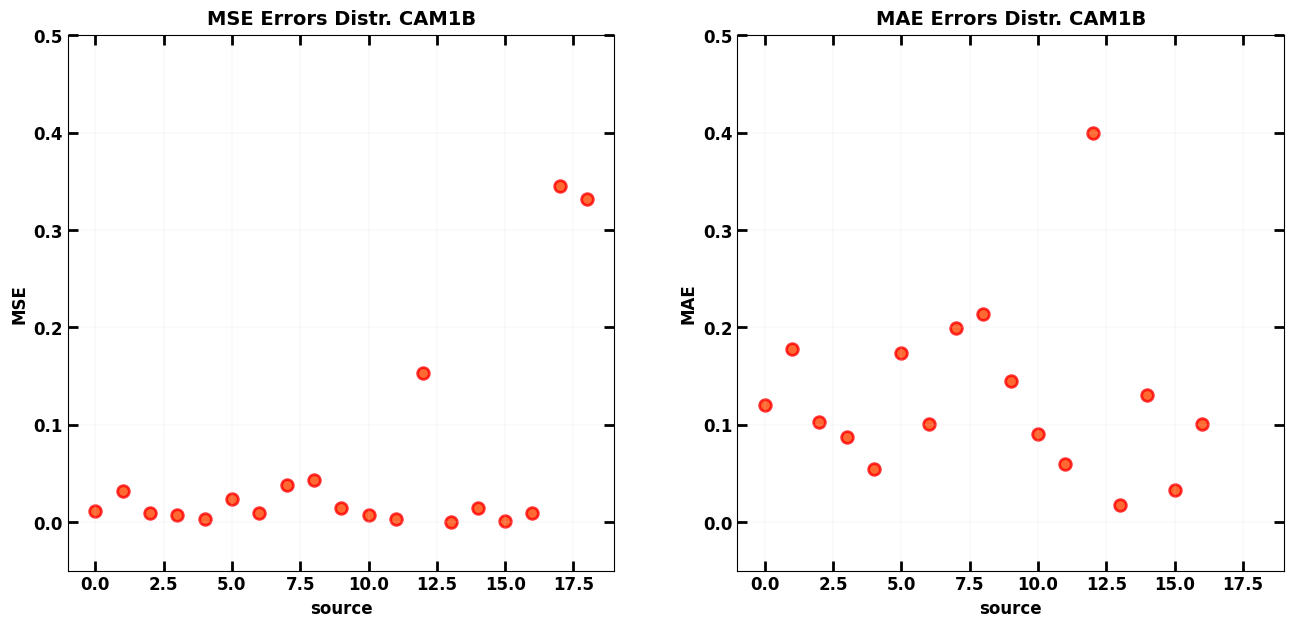

In [9]:
from dummymoon import sequence_plot

def check_sources_errors(
    iros_data: dict,
    catalogs: tuple,
) -> None:

    def source_errs(
        catalog: np.recarray,
        source_name: str,
        ra: float,
        dec: float,
        err: str,
    ) -> float:
        def dev(a, b) -> float:
            if err == "MSE":
                f = np.square
            elif err == "MAE":
                f = np.abs
            return f(a - b)
        cat_source_ra = catalog.data[catalog.data["NAME"] == source_name]["RA"][0]
        cat_source_dec = catalog.data[catalog.data["NAME"] == source_name]["DEC"][0]
        return 0.5 * dev(ra, cat_source_ra) + dev(dec, cat_source_dec)
        
    for camera, cat in zip(
        iros_data.keys(), catalogs,
    ):
        print(f"# CAMERA {camera.upper()}")
        mse_errors, mae_errors = [], []
        for name, ra, dec in zip(
            iros_data[camera]["catalog_name"]["data"],
            iros_data[camera]["ra"]["data"],
            iros_data[camera]["dec"]["data"],
        ):
            print(
                f"  - {name.upper()} MSE: {source_errs(cat, name, ra, dec, "MSE"):0.6f}\n"
                f"    {name.upper()} MAE: {source_errs(cat, name, ra, dec, "MAE"):0.6f}"
            )
            mse_errors.append(source_errs(cat, name, ra, dec, "MSE"))
            mae_errors.append(source_errs(cat, name, ra, dec, "MAE"))
        sequence_plot(
            input_sequence=[mse_errors, mae_errors],
            title=[e + f" Errors Distr. {camera.upper()}" for e in ["MSE", "MAE"]],
            xlabel=["source"]*2,
            ylabel=["MSE", "MAE"],
            style=["scatter"]*2,
            offsetx=[(-1, 1)]*2,
            offsety=[(-0.05, 0.5)]*2,
        )
        print("\n")
            

check_sources_errors(
    iros_data=dataset,
    catalogs=(catalogA, catalogB),
)

# CAMERA CAM1A
  - SCOX1 RA residues: -0.095258
    SCOX1 DEC residues: 0.021686
  - GX5-1 RA residues: -0.036065
    GX5-1 DEC residues: 0.008379
  - GX349+2 RA residues: -0.117501
    GX349+2 DEC residues: 0.013515
  - GX17+2 RA residues: -0.110306
    GX17+2 DEC residues: 0.011937
  - GX9+1 RA residues: -0.059143
    GX9+1 DEC residues: 0.010600
  - GX340+0 RA residues: 0.025373
    GX340+0 DEC residues: -0.006433
  - GX3+1 RA residues: 0.027499
    GX3+1 DEC residues: 0.007511
  - GX13+1 RA residues: -0.159025
    GX13+1 DEC residues: 0.007495
  - X1820-303 RA residues: -0.116494
    X1820-303 DEC residues: -0.004009
  - CIRX1 RA residues: 0.007971
    CIRX1 DEC residues: -0.014586
  - GX9+9 RA residues: -0.085718
    GX9+9 DEC residues: 0.016770
  - GROJ1655-40 RA residues: -0.040533
    GROJ1655-40 DEC residues: 0.002615
  - X1735-444 RA residues: -0.790419
    X1735-444 DEC residues: 0.009689
  - GRS1915+105 RA residues: -0.286776
    GRS1915+105 DEC residues: 0.042258
  - X1705

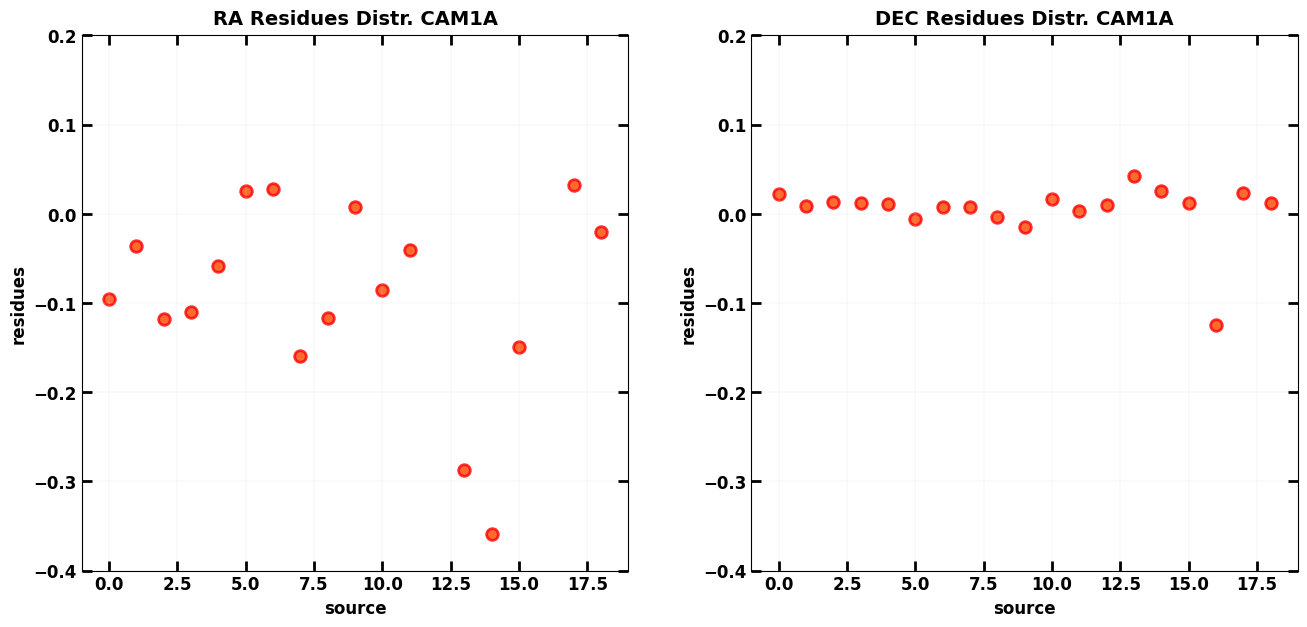



# CAMERA CAM1B
  - SCOX1 RA residues: -0.035914
    SCOX1 DEC residues: -0.102609
  - GX5-1 RA residues: 0.001122
    GX5-1 DEC residues: -0.177428
  - GX349+2 RA residues: -0.021276
    GX349+2 DEC residues: -0.092502
  - GX17+2 RA residues: 0.004663
    GX17+2 DEC residues: -0.084669
  - GX9+1 RA residues: -0.004434
    GX9+1 DEC residues: -0.052663
  - GX340+0 RA residues: -0.046390
    GX340+0 DEC residues: -0.149964
  - GX3+1 RA residues: -0.008211
    GX3+1 DEC residues: -0.096996
  - GX13+1 RA residues: 0.008995
    GX13+1 DEC residues: -0.195144
  - X1820-303 RA residues: 0.012501
    X1820-303 DEC residues: -0.206933
  - CIRX1 RA residues: -0.097170
    CIRX1 DEC residues: -0.095912
  - GX9+9 RA residues: -0.010595
    GX9+9 DEC residues: -0.084990
  - GROJ1655-40 RA residues: -0.024831
    GROJ1655-40 DEC residues: -0.047142
  - X1735-444 RA residues: -0.017410
    X1735-444 DEC residues: -0.390990
  - GRS1915+105 RA residues: 0.010093
    GRS1915+105 DEC residues: -0.01267

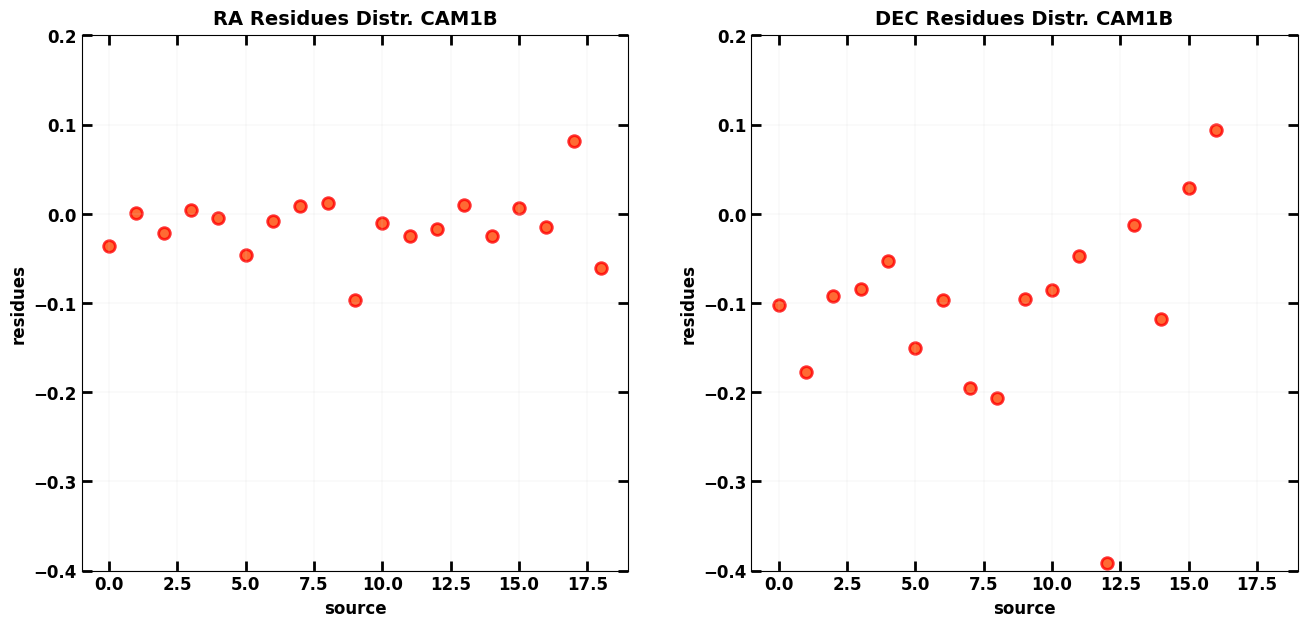

In [10]:
from dummymoon import sequence_plot

def check_sources_res(
    iros_data: dict,
    catalogs: tuple,
) -> None:

    def source_res(
        catalog: np.recarray,
        source_name: str,
        ra: float,
        dec: float,
    ) -> float:
        cat_source_ra = catalog.data[catalog.data["NAME"] == source_name]["RA"][0]
        cat_source_dec = catalog.data[catalog.data["NAME"] == source_name]["DEC"][0]
        return ra - cat_source_ra, dec - cat_source_dec
        
    for camera, cat in zip(
        iros_data.keys(), catalogs,
    ):
        print(f"# CAMERA {camera.upper()}")
        ra_res, dec_res = [], []
        for name, ra, dec in zip(
            iros_data[camera]["catalog_name"]["data"],
            iros_data[camera]["ra"]["data"],
            iros_data[camera]["dec"]["data"],
        ):
            rra, rdec = source_res(cat, name, ra, dec)
            print(
                f"  - {name.upper()} RA residues: {rra:0.6f}\n"
                f"    {name.upper()} DEC residues: {rdec:0.6f}"
            )
            ra_res.append(rra); dec_res.append(rdec)
        sequence_plot(
            input_sequence=[ra_res, dec_res],
            title=[e + f" Residues Distr. {camera.upper()}" for e in ["RA", "DEC"]],
            xlabel=["source"]*2,
            ylabel=["residues"]*2,
            style=["scatter"]*2,
            offsetx=[(-1, 1)]*2,
            offsety=[(-0.4, 0.2)]*2,
        )
        print("\n")
            

check_sources_res(
    iros_data=dataset,
    catalogs=(catalogA, catalogB),
)

In [14]:
def check_pos_w_best_coord(
    iros_data=dataset,
    catalogs=(catalogA, catalogB),
    sigma=5,
) -> None:

    source_in_errbox_camA = []
    source_in_errbox_camB = []
    errboxes = (source_in_errbox_camA, source_in_errbox_camB)

    camA, camB = iros_data.keys()
    sources_ra = dataset[camB]["ra"]["data"]
    sources_dra = dataset[camB]["dra"]["data"]
    sources_dec = dataset[camA]["dec"]["data"]
    sources_ddec = dataset[camA]["ddec"]["data"]

    for cat, camera, errbox in zip(
        catalogs,
        iros_data.keys(),
        errboxes,
    ):
        print(f"# CAMERA {camera.upper()}, {sigma} SIGMA ERRBOX")
        for name, ra, dec, dra, ddec in zip(
            dataset[camera]["catalog_name"]["data"],
            sources_ra, sources_dec,
            sources_dra, sources_ddec,
        ):
            cat_source_ra = cat.data[cat.data["NAME"] == name]["RA"][0]
            cat_source_dec = cat.data[cat.data["NAME"] == name]["DEC"][0]
            errbox.append(
                int((np.abs(cat_source_ra - ra) < sigma*dra) & (np.abs(cat_source_dec - dec) < sigma*ddec)),
            )
                
            print(
                f"  - {name.upper()} inside error box: {bool(errbox[-1])}"
            )
    
        print(
            f"# IROS accuracy {camera.upper()}: {np.array(errbox).sum()*100/len(iros_data[camera]["catalog_name"]["data"]):0.2f}%\n"
        )


check_pos_w_best_coord(
    iros_data=dataset,
    catalogs=(catalogA, catalogB),
    sigma=5,
)

# CAMERA CAM1A, 5 SIGMA ERRBOX
  - SCOX1 inside error box: True
  - GX5-1 inside error box: True
  - GX349+2 inside error box: True
  - GX17+2 inside error box: True
  - GX9+1 inside error box: True
  - GX340+0 inside error box: True
  - GX3+1 inside error box: True
  - GX13+1 inside error box: True
  - X1820-303 inside error box: True
  - CIRX1 inside error box: True
  - GX9+9 inside error box: True
  - GROJ1655-40 inside error box: True
  - X1735-444 inside error box: True
  - GRS1915+105 inside error box: False
  - X1705-440 inside error box: True
  - GX354-0 inside error box: True
  - X1636-536 inside error box: False
  - SERX1 inside error box: False
  - IGRJ17091-3624 inside error box: True
# IROS accuracy CAM1A: 84.21%

# CAMERA CAM1B, 5 SIGMA ERRBOX
  - SCOX1 inside error box: True
  - GX5-1 inside error box: True
  - GX349+2 inside error box: True
  - GX17+2 inside error box: True
  - GX9+1 inside error box: True
  - GX340+0 inside error box: True
  - GX3+1 inside error box: T

In [16]:
sources_dra_b = dataset[cam_b]["dra"]["data"]
sources_ddec_b = dataset[cam_a]["ddec"]["data"]

sources_dra_w = dataset[cam_a]["dra"]["data"]
sources_ddec_w = dataset[cam_b]["ddec"]["data"]

# it's better with the boxes from best dra and ddec
7*sources_dra_b*100 / (2*sources_dra_w), 5*sources_ddec_b*100 / (2*sources_ddec_w)

(array([113.22948338,  32.16860459,  74.49328833,  20.95829765,
         31.85673706,  90.70464504,  42.06165262,  22.09172109,
         15.18464724, 176.01611045,  54.30217576,  83.83737459,
         49.10948125,  25.36149596,  72.14525955,  54.02832896,
         93.52125347,   2.53169456,  72.25523918]),
 array([ 57.51539562,  24.02401011,  58.33987905,  22.95077967,
         25.10321307,  82.04467428,  30.03368056,  21.83883808,
         10.42779669, 202.2092023 ,  35.91807611,  69.36931071,
         39.25033933,  55.10787135,  62.15252311,  40.07858756,
         94.05785495,  37.08585421,  55.93897887]))

In [8]:
import matplotlib.pyplot as plt
from mbloodmoon.mask import decode, model_sky
from mbloodmoon.images import upscale, compose
from scipy.signal import correlate


def make_sky(
    iros_data: dict,
    camera: str,
    wfm: object,
    iros_output: dict = None,
) -> np.array:
    
    def make_source(
        shiftx: float,
        shifty: float,
        fluence: float,
        pos: tuple[int, int],
    ) -> np.array:
        def args() -> tuple[callable]:
            cut = (40, 20)
            y1, y2 = pos[0] - cut[0], pos[0] + cut[0]
            x1, x2 = pos[1] - cut[1], pos[1] + cut[1]
            return slice(y1, y2), slice(x1, x2)
        model = model_sky(wfm, shiftx, shifty, fluence)
        canva = np.zeros_like(model)
        canva[args()] = model[args()]
        return canva
    
    def get_backgroud() -> np.array:

        def sim_BG(rate: float) -> np.array:
            def encode(bg: np.array) -> np.array:
                return correlate(wfm.mask, bg, mode='valid')*wfm.bulk
            aperture = wfm.mask.sum()
            det_eff_response = wfm.bulk.sum()/wfm.mask.size
            norm = 1/(aperture*det_eff_response)
            det_bg = encode(np.random.poisson(rate, wfm.sky_shape))
            return norm*decode(wfm, det_bg)
        
        def get_residues() -> np.array:
            return (iros_output[camera]["sky_residues"]).copy()
        
        if iros_output is not None:
            return get_residues()
        else:
            return sim_BG(10)
    
    sky = get_backgroud()#; a = sky.max()
    for x, y, shiftx, shifty, fluence in zip(
        iros_data[camera]["x"]["data"],
        iros_data[camera]["y"]["data"],
        iros_data[camera]["shift_x"]["data"],
        iros_data[camera]["shift_y"]["data"],
        iros_data[camera]["fluence"]["data"],
    ):
        sky += make_source(shiftx, shifty, fluence, (y, x))
    
    sky[sky < 0] = 0
    return sky




PARAMS = {
    "txtfs": 3.8,
    "txtfw": "bold",
}

def camera_sky(
    sky: np.array,
    iros_data: dict,
    camera: str,
    ups_x: int = 1,
    ups_y: int = 8,
    save_to: str = None,
) -> None:

    fig, ax = plt.subplots(1, 1, figsize=(8, 10), dpi=150)
    for x, y, name in zip(
        iros_data[camera]["x"]["data"],
        iros_data[camera]["y"]["data"],
        iros_data[camera]["catalog_name"]["data"],
    ):
        ax.scatter(x*ups_x, y*ups_y, s=30, facecolors="none",
                   edgecolors="white", alpha=1, linewidth=0.5)
        ax.text(x*ups_x + 50, y*ups_y + 100, name.upper(), color="white",
                fontsize=PARAMS["txtfs"], fontweight=PARAMS["txtfw"])
    
    ax.imshow(upscale(sky, ups_x, ups_y), cmap='inferno')
    ax.set_title(f"{camera.upper()} Sky", fontsize=12, pad=8, fontweight='bold')
    plt.axis("off")
    plt.tight_layout()
    if save_to is not None: plt.savefig(save_to)
    plt.show()


def composed_camera(
    skys: tuple[np.array, np.array],
    iros_data: dict,
    ups_x: int = 1,
    ups_y: int = 8,
    save_to: str = None,
) -> None:
    
    camA, camB = iros_data.keys()
    composed_sky, _ = compose(*tuple(upscale(sky, ups_x, ups_y) for sky in skys), strict=False)
    fig, ax = plt.subplots(1, 1, figsize=(8, 10), dpi=150)
    for x, y, name in zip(
        iros_data[camA]["x"]["data"],
        iros_data[camA]["y"]["data"],
        iros_data[camA]["catalog_name"]["data"],
    ):
        #ax.scatter(x*ups_x, y*ups_y + 53, s=30, facecolors="none",
        #           edgecolors="white", alpha=1, linewidth=0.5)
        ax.text(x*ups_x + 50, y*ups_y + 150, name.upper(), color="white",
                fontsize=PARAMS["txtfs"], fontweight=PARAMS["txtfw"])
    
    ax.imshow(composed_sky, cmap='inferno')
    ax.set_title(
        f"Composed Sky {camA.upper()} - {camB.upper()}",
        fontsize=12, pad=8, fontweight='bold')
    plt.axis("off")
    plt.tight_layout()
    if save_to is not None: plt.savefig(save_to)
    plt.show()

In [9]:
skyA = make_sky(
    iros_data=dataset,
    camera=cam_a,
    wfm=wfm,
    iros_output=iros_output,
)

skyB = make_sky(
    iros_data=dataset,
    camera=cam_b,
    wfm=wfm,
    iros_output=iros_output,
)

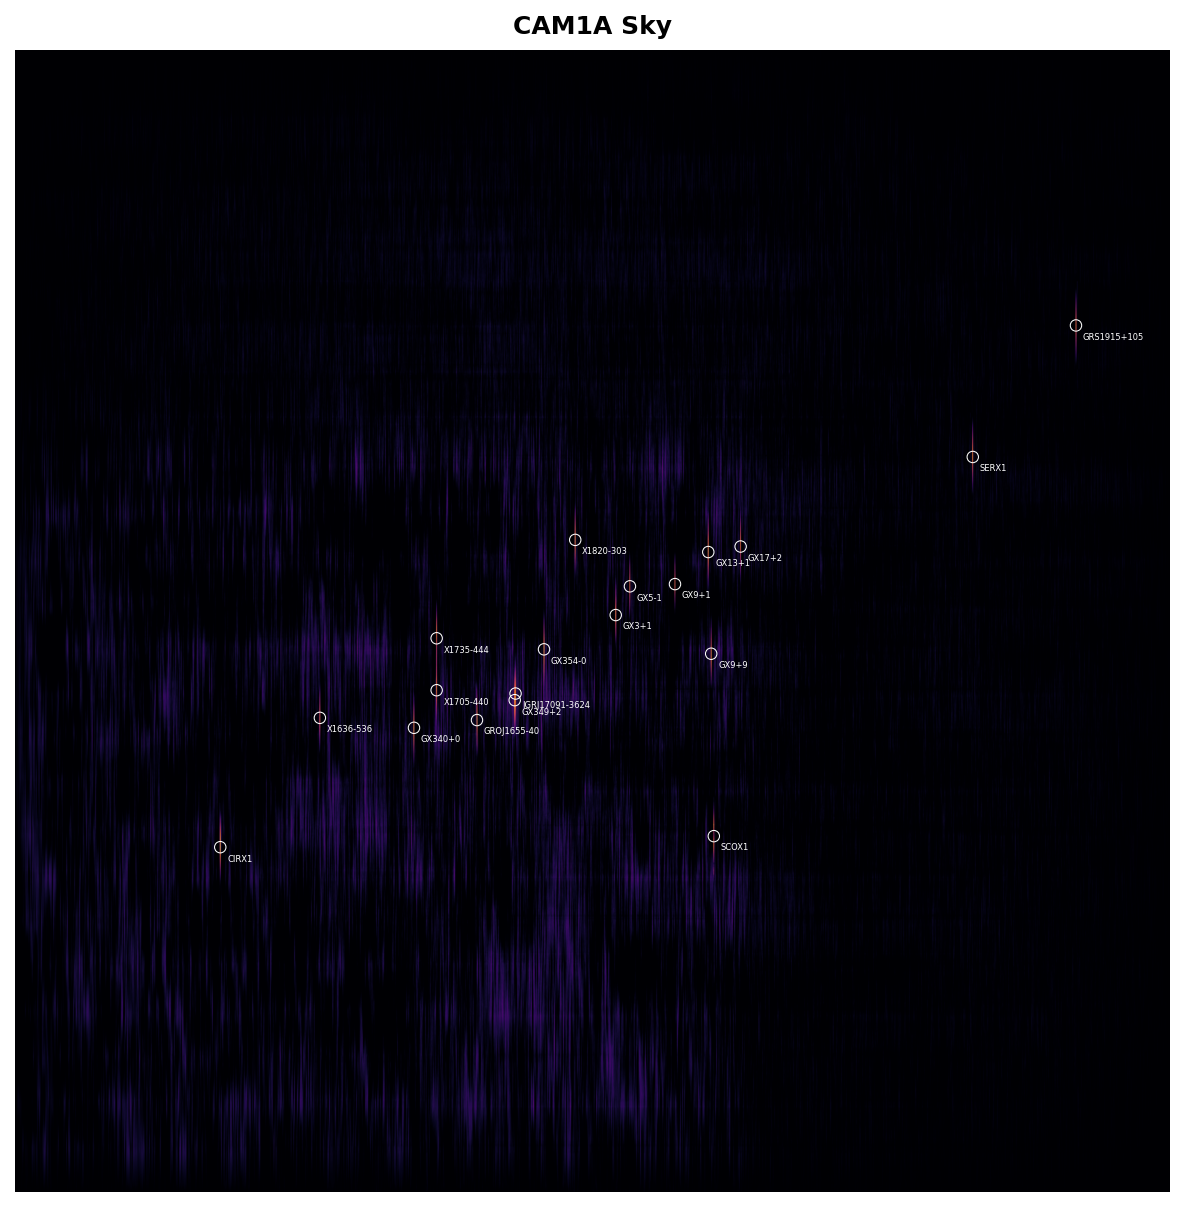

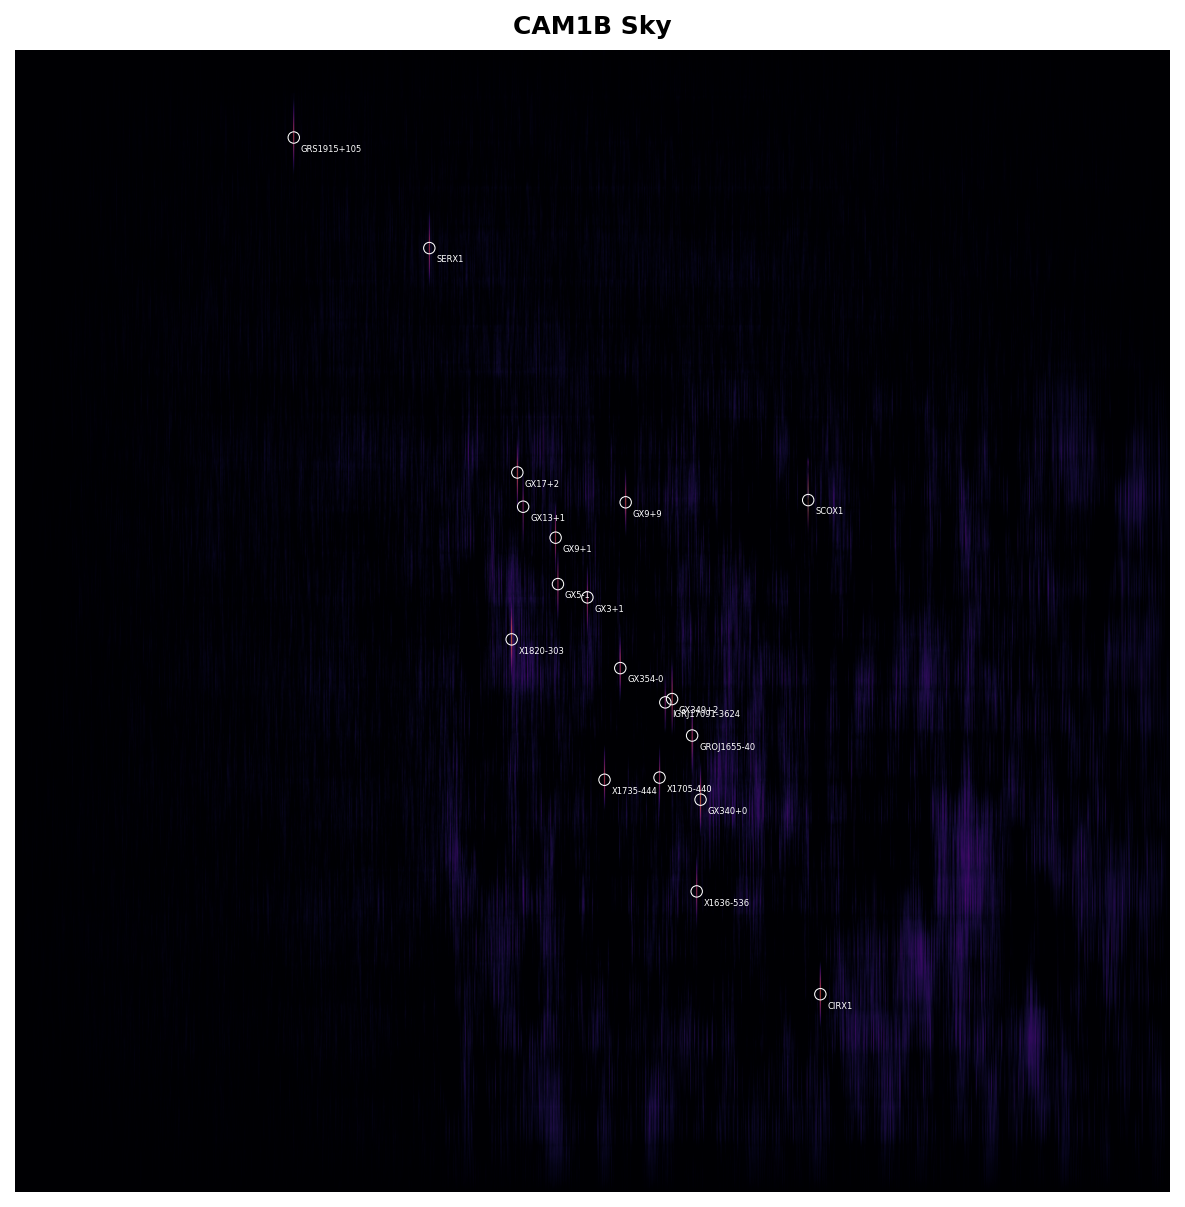

In [10]:
camera_sky(
    sky=skyA,
    iros_data=dataset,
    camera=cam_a,
    #save_to=root_path+f"GalCen{cam_a.upper()}_sky.png",
)

camera_sky(
    sky=skyB,
    iros_data=dataset,
    camera=cam_b,
    #save_to=root_path+f"GalCen{cam_b.upper()}_sky.png",
)

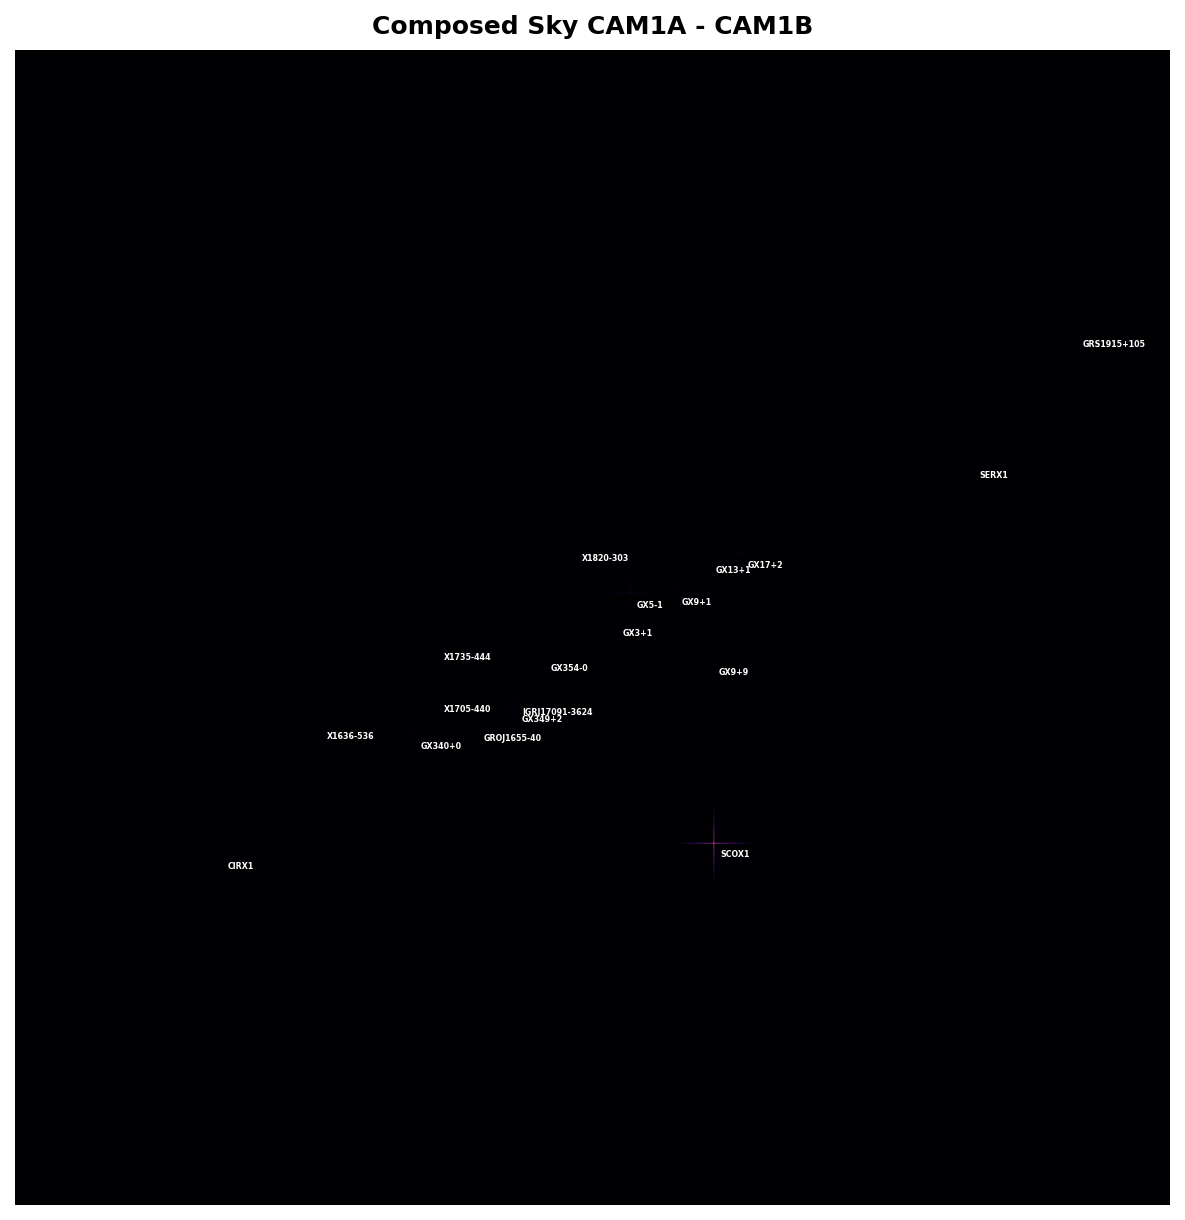

In [10]:
composed_camera(
    skys=(skyA, skyB),
    iros_data=dataset,
    #save_to=root_path+f"GalCen{cam_b.upper()}_sky.png",
)

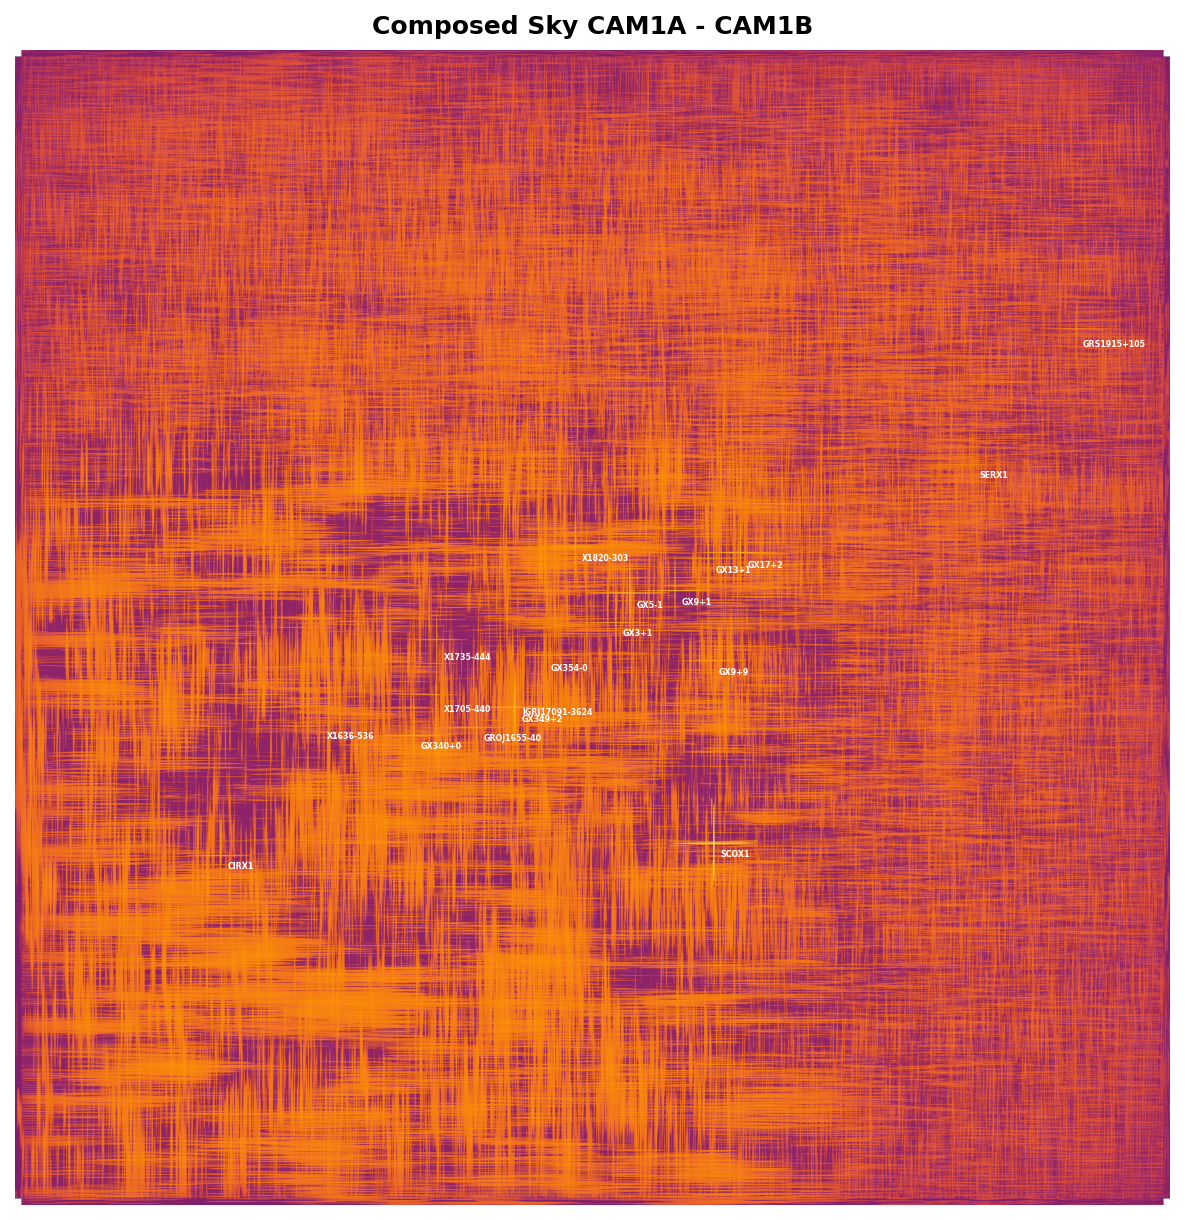

In [7]:
composed_camera(
    skys=(skyA, skyB),
    iros_data=dataset,
    #save_to=root_path+f"GalCen{cam_b.upper()}_sky.png",
)

In [17]:
sky = iros_output["cam1a"]["sky_residues"]
snr = np.random.randint(0, 10, (sky.shape))

In [ ]:
from mbloodmoon.images import upscale, compose
from iros_wrappers import save_sky, load_sky

save_sky(
    sky=upscale(sky, upscale_y=8),
    snr=upscale(snr, upscale_y=8),
    sdl=sdlA,
    wfm=wfm,
    save_to=root_path + f"skyfitstest{0}.fits",
)

test_sky, test_snr = load_sky(root_path + f"skyfitstest{0}.fits")

# Saving Sky...


 [astropy.io.fits.verify]


# Saving completed!
